<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/Dimensionality_Reduction_Student_v3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction — in six steps

**AAU Business School · MSc**

You have a table with far too many columns. You want one picture and one sentence.
This notebook gets you there in six steps.

| | Step | What it does |
|---|---|---|
| 1 | **Load** | read the data |
| 2 | **Understand + clean** | look at the data, then find and fix what is wrong with it — **you do this one** |
| 3 | **Standardise** | put every column on the same scale |
| 4 | **Run PCA** | squeeze 19 columns into a handful |
| 5 | **Read it** | how many components, and what they mean |
| 6 | **Plot it** | the picture you actually wanted |

Then a short look at **t-SNE and UMAP**, and four more exercises (2–5).

**Exercise 1 is yours to do**, and it has two parts:
**Part A — understand the data**, **Part B — preprocess the data**. Both live inside Step 2.

> Every cell is short and does one thing. Run them in order, top to bottom.


> ### ✏️ Student version
> The exercise cells in this notebook are **blank on purpose** — they are yours to fill in.
> There is a separate solutions copy with every one of them worked out.

---
## Step 0 · Setup

Two cells. The first installs UMAP (Colab does not have it); the second imports everything.

In [3]:
!pip install umap-learn -q

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

---
## Step 1 · Load the data

Cities around the world, scored on how good they are to live and work in.
One row per city.

In [5]:
url = "https://sds-aau.github.io/SDS-master/M1/data/cities.csv"
cities = pd.read_csv(url)

cities.head()

,place,alpha-2,region,sub-region,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,free_wifi_available,internet_speed,freedom_score,peace_score,safety,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,Budapest,HU,Europe,Eastern Europe,1364.0,152.41,1273.0,1.73,1.73,1.0,0.4,31.0,0.6,0.8,0.60,52.7,28.17,1.0,0.27,0.6,0.40,0.80,0.86,1.00,0.0
1,Chiang Mai,TH,Asia,South-eastern Asia,777.0,98.88,780.0,0.85,0.85,0.8,0.6,14.0,0.2,0.4,0.80,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.75,0.40,0.0
2,Phuket,TH,Asia,South-eastern Asia,1012.0,155.43,1714.0,1.41,1.41,0.8,0.4,14.0,0.2,0.4,0.80,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.75,0.82,0.0
3,Bangkok,TH,Asia,South-eastern Asia,1197.0,131.41,1158.0,2.12,2.12,1.0,1.0,24.0,0.2,0.4,0.77,78.8,44.53,0.8,0.80,1.0,0.42,0.82,0.72,1.00,0.0
4,Ko Samui,TH,Asia,South-eastern Asia,1352.0,169.56,1347.0,1.41,1.41,0.8,0.4,15.0,0.2,0.4,0.80,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.80,0.0


---
# Step 2 · 🛠 **Exercise 1** — the data is yours now

This is the one hands-on block of the notebook, and it has **two parts**:

| | Part | What you do | Time |
|---|---|---|---|
| **A** | **Understand the data** | look at it, and write down what you expect to find | ~10 min |
| **B** | **Preprocess the data** | find and fix the three things that are wrong with it | ~15 min |

> **Why you do this and not me.** You already know *what* is wrong with this file — we said it in the
> lecture. That is not the point. The point is **how to find it**.
>
> Knowing that *this* file has a duplicate column helps you once. Knowing *how to spot* a
> duplicate column helps you every time.

There is a **checkpoint** at the end of Part B that tells you whether you got them, and the answers
are right after it — so nobody gets stuck or falls behind.

---
# Part A · Understand the data

Five short cells, then four questions. Work in pairs.

### A1 · How big is this table?

Print the number of rows and the number of columns.

```python
cities.shape[0]   # rows
cities.shape[1]   # columns
```

In [6]:
# A1 -- print the number of rows and columns



### A2 · What are the columns called?

List the column names.

*Hint: `cities.columns`*

In [7]:
# A2 -- list the column names



### A3 · Look at every column at once

A list of names tells you nothing about what is *in* the columns. `.T` flips the table on its
side, so each **column** becomes a **row** with a few example values next to it. On a wide table
this is the most useful first look there is.

*Hint: `cities.head(3).T`*

In [8]:
# A3 -- show the first 3 rows, transposed



### A4 · What kinds of city are in here?

Count how many cities fall in each `region`.

*Hint: `.value_counts()`*

In [9]:
# A4 -- count the cities per region



### A5 · How big are the numbers?

Show the summary statistics for every numeric column. Look especially at the `mean` row — are all
the columns on the same scale, or do some run in thousands while others run between 0 and 1?

*Hint: `cities.describe().T`*

In [10]:
# A5 -- summary statistics for every numeric column



---
### 🛠 A6 · Now write down what you expect — **before** we analyse anything

**Five minutes, in pairs. Write your answers down — we check every one of them later in the notebook.**

1. **Sort the column names into groups** that you think measure the same *kind* of thing.
   Give each group a short name. **How many groups did you end up with?**  → **____**

2. **Which two columns do you suspect are nearly the same thing?**
   (There is one pair here that will surprise you.)  → **____________** and **____________**

3. **Which columns are not really measurements of the city at all?**

4. From A5: **which column has the largest numbers?** Keep that name — it comes back in Step 3.

> Why do this first? A principal component *is* a group of columns that move together. If you can
> group them by **meaning** now, then what PCA finds later will look like confirmation of something
> you already worked out — instead of magic. And a guess you have written down is a guess you care
> about.

**Do not scroll on until you have written something for all four.**

---
# Part B · Preprocess the data

Three things are wrong with this file, and **you are going to find all three yourself.**
Work through **B1**, **B2**, **B3**, **B4**.

---
### B1 · Find the pair of identical columns

In Part A you guessed which two columns might be nearly the same. **Now test your guess.**

Two columns are identical when comparing them gives `True` in every row:

```python
(cities["column_one"] == cities["column_two"]).all()
```

`True` means they are the same column twice. `False` means keep looking.

**Your turn.** Test your guess. If it comes back `False`, try another pair — you have a short list
of plausible candidates from Part A.

In [11]:
# B1 -- test whether two columns are identical



Once you have found the pair, **drop one of the two.**

```python
cities = cities.drop(columns="the_one_you_are_dropping")
```

In [12]:
# B1 -- drop one of the duplicated columns



---
### B2 · Find the columns with impossible values

Most broken numbers give themselves away at the **extremes**. So look at the smallest and largest
value in every column at once:

In [13]:
cities.describe().T[["min", "max"]]

,min,max
cost_nomad,3.870000e+02,1.012100e+04
cost_coworking,1.000000e-02,1.524460e+03
cost_expat,2.960000e+02,1.340600e+04
coffee_in_cafe,0.000000e+00,1.372000e+01
cost_beer,0.000000e+00,1.372000e+01
places_to_work,0.000000e+00,1.000000e+00
free_wifi_available,0.000000e+00,1.000000e+00
internet_speed,0.000000e+00,1.970000e+02
freedom_score,-5.723731e-17,1.000000e+00
peace_score,-4.674509e-17,1.000000e+00


**Read down the `min` column and ask: is this value possible?**

*(Ignore the scientific notation — pandas uses it when a column mixes very large and very small
numbers. Just look for a **minus sign** where there should not be one.)*

Two of these should stop you. A score that is supposed to run from 0 to 1 cannot be negative, and a
value like `-3.51e-17` is not a measurement — it is a rounding error left behind by whatever
produced this file.

**Your turn.** Round those two columns to a sensible number of decimals, which turns the rubbish
into a clean `0`:

```python
cities["column_name"] = cities["column_name"].round(6)
```

In [14]:
# B2 -- round the two columns with impossible values



---
### B3 · Find the column that is not an independent measurement

This one is **reasoning, not code.**

One column is not something anybody measured about a city. It is a **summary of the other columns**
— the website works it out from them and publishes it as an overall verdict.

Including it alongside its own ingredients would be like adding "the average" as an extra column: it
adds no new information, and it would dominate everything.

**Your turn.** Look back at the column names. Which one is it? Write the name here → `____________`

*(No code to run for B3. We set the column aside in step 2c, not delete it — it becomes a free
check on our results later.)*

---
### B4 · Check for missing values

The one check to run on **every** dataset you are ever given, before anything else:

In [15]:
# B4 -- how many missing values does each column have?
#      hint: .isna().sum()



---
### ✅ Checkpoint

Run this to see how you did. All three should say `True`.

*(If you ran the whole notebook in one go without filling in the cells above, these will say
`False` — that is expected, not a bug. The next cell fixes everything.)*

In [16]:
print("B1  duplicate column dropped :", "cost_beer" not in cities.columns)
print("B2  no impossible negatives  :", cities["peace_score"].min() >= 0)
print("    columns remaining        :", cities.shape[1], "(should be 24)")

B1  duplicate column dropped : False
B2  no impossible negatives  : False
    columns remaining        : 25 (should be 24)


### The answers

Run this cell **whatever happened above** — it is safe to run even if you already fixed everything,
and it guarantees everyone continues from the same place.

In [17]:
cities = cities.drop(columns="cost_beer", errors="ignore")

cities["peace_score"] = cities["peace_score"].round(6)
cities["fragile_states_index"] = cities["fragile_states_index"].round(6)

print("columns now:", cities.shape[1])
print("smallest peace_score:", cities["peace_score"].min())

columns now: 24
smallest peace_score: -0.0


**B1** was `coffee_in_cafe` and `cost_beer` — not merely similar, **the identical column twice**.
Somebody copied one over the other upstream.

**B2** was `peace_score` and `fragile_states_index`.

**B3** was `life_score` — handled in 2c below.

**B4** — whatever your answer was, that is the honest state of the file. If there were missing values,
we deal with them in the next cell.

> `-0.0` is just "negative zero". It is exactly zero, and harmless.

> **📌 The three checks, worth keeping.** `(a == b).all()` for duplicated columns ·
> `.describe().T[["min","max"]]` for impossible values · `.isna().sum()` for missing ones.
> Ten seconds each, and they will save you from a ruined analysis more than once.

---
### 2c · Pick the columns we will actually use

We drop the **labels** (they are text, not measurements) and we drop **`life_score`**.

Why drop `life_score`? Because the website calculates it *from the other columns*. Including it
would be like adding "the average" as an extra column — it tells us nothing new, and it would
dominate everything. We keep it aside and use it as a **check** at the end.

In [18]:
labels = cities[["place", "alpha-2", "region", "sub-region", "life_score"]]

features = cities.drop(columns=["place", "alpha-2", "region", "sub-region", "life_score"])
features = features.fillna(features.median())

print("features we will use:", features.shape[1])
features.head()

features we will use: 19


,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,places_to_work,free_wifi_available,internet_speed,freedom_score,peace_score,safety,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,nightlife,weed
0,1364.0,152.41,1273.0,1.73,1.0,0.4,31.0,0.6,0.8,0.60,52.7,28.17,1.0,0.27,0.6,0.40,0.80,1.00,0.0
1,777.0,98.88,780.0,0.85,0.8,0.6,14.0,0.2,0.4,0.80,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.40,0.0
2,1012.0,155.43,1714.0,1.41,0.8,0.4,14.0,0.2,0.4,0.80,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.82,0.0
3,1197.0,131.41,1158.0,2.12,1.0,1.0,24.0,0.2,0.4,0.77,78.8,44.53,0.8,0.80,1.0,0.42,0.82,1.00,0.0
4,1352.0,169.56,1347.0,1.41,0.8,0.4,15.0,0.2,0.4,0.80,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.0


---
## Why bother reducing at all?

Two reasons, both visible in one cell each.

### Reason 1 — you cannot look at 19 columns

In [19]:
n = features.shape[1]
print("to see every pair of columns you would need", int(n * (n - 1) / 2), "scatter plots")

to see every pair of columns you would need 171 scatter plots


### Reason 2 — the columns repeat each other

Dark red squares = two columns that move together. Look for the **blocks** along the diagonal.

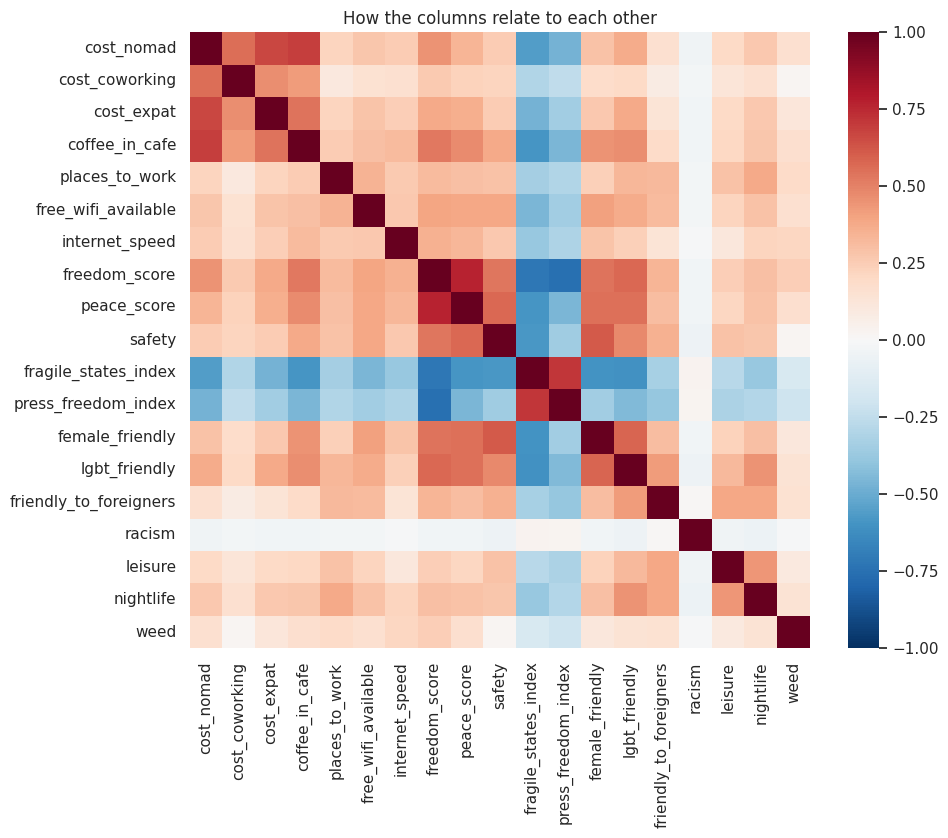

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("How the columns relate to each other")
plt.show()

You can see the cost columns clumping together, and the safety/institutions columns clumping
together. **19 columns, but nowhere near 19 separate pieces of information.** That is exactly
what PCA is for.

> **↩ Exercise 1, Part A, question 1.** Count the blocks on the diagonal. How does that compare with the
> number of groups you wrote down?
>
> You grouped the columns by what they **mean**. This picture groups them by how they **move**.
> The fact that those two give similar answers is the whole reason PCA works — and where they
> *disagree* is usually the most interesting thing in the dataset.

---
## Step 3 · Standardise

**This is the step people forget, and it ruins everything.**

Look at the scale of these columns:

In [21]:
features[["cost_expat", "internet_speed", "safety"]].describe().round(2)

,cost_expat,internet_speed,safety
count,780.00,780.00,780.00
mean,1880.91,13.60,0.68
std,1266.15,18.21,0.21
min,296.00,0.00,0.00
25%,1010.00,2.00,0.60
50%,1646.00,6.00,0.60
75%,2409.75,19.25,0.80
max,13406.00,197.00,1.00


`cost_expat` is in thousands of dollars. `safety` is between 0 and 1.

PCA looks for the columns that **vary the most**. On these raw numbers it would decide that rent
is the most important thing in the world — not because it is, but because it is measured in
dollars instead of a 0–1 score.

Here is that mistake, live:

In [22]:
wrong = PCA(n_components=2).fit(features)

pd.Series(abs(wrong.components_[0]), index=features.columns).sort_values().tail(4)

,0
fragile_states_index,1.492187e-27
cost_expat,6.855817e-26
cost_nomad,6.860413e-26
racism,1.000000e+00


The first component is **almost entirely one column** — the one with the biggest numbers.
That is not a finding about cities. That is a finding about dollars.

**The fix is one line.** Standardising turns every column into "how many standard deviations
above or below average", so they are all comparable.

In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

print("mean of every column is now ~0:", X.mean().round(3))
print("standard deviation is now ~1: ", X.std().round(3))

mean of every column is now ~0: 0.0
standard deviation is now ~1:  1.0


---
## Step 4 · Run PCA

Two lines. This is the easy part.

In [24]:
pca = PCA(n_components=5, random_state=42)
scores = pca.fit_transform(X)

print("shape before:", X.shape)
print("shape after: ", scores.shape)

shape before: (780, 19)
shape after:  (780, 5)


19 columns became 5. Those 5 new columns are the **principal components** — PC1, PC2, and so on.

Each one is a *mix* of the original columns. PC1 is the single mix that captures the most
variation between cities; PC2 is the next most, and so on.

---
## Step 5 · Read the result

### 5a · How much did we keep?

In [25]:
variance = pca.explained_variance_ratio_ * 100

print("PC1 captures", variance[0].round(1), "% of all the variation")
print("PC2 captures", variance[1].round(1), "%")
print("all 5 together:", variance.sum().round(1), "%")

PC1 captures 37.0 % of all the variation
PC2 captures 9.0 %
all 5 together: 64.0 %


### 5b · How many components should we keep?

Fit PCA once with **all** components, then look at the picture. You are looking for the **elbow**
— the point where the bars stop dropping sharply and flatten out.

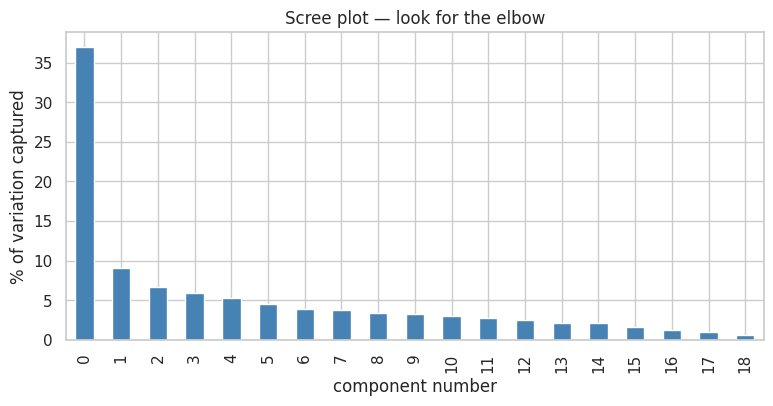

In [26]:
pca_all = PCA(random_state=42).fit(X)

plt.figure(figsize=(9, 4))
pd.Series(pca_all.explained_variance_ratio_ * 100).plot.bar(color="steelblue")
plt.xlabel("component number")
plt.ylabel("% of variation captured")
plt.title("Scree plot — look for the elbow")
plt.show()

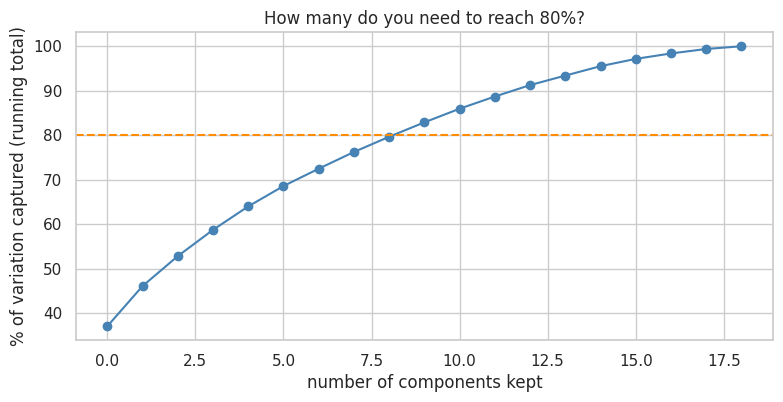

In [27]:
plt.figure(figsize=(9, 4))
pd.Series(np.cumsum(pca_all.explained_variance_ratio_) * 100).plot(marker="o", color="steelblue")
plt.axhline(80, color="darkorange", linestyle="--")
plt.xlabel("number of components kept")
plt.ylabel("% of variation captured (running total)")
plt.title("How many do you need to reach 80%?")
plt.show()

**There is no single right answer.** Three common rules:

| Rule | What it says |
|---|---|
| **Elbow** | stop where the scree plot flattens |
| **80% rule** | keep enough to reach 80% of the variation |
| **Just 2** | if you only want a picture, keep 2 |

Pick one, and **say in your report which one you used**. That sentence is worth marks.

### 5c · What do the components mean?

This is the important part. The **loadings** tell you which original columns make up each
component.

In [50]:
pca.components_.shape

(5, 19)

In [28]:
loadings = pd.DataFrame(pca.components_.T,
                        index=features.columns,
                        columns=["PC1", "PC2", "PC3", "PC4", "PC5"])

loadings.round(2)

,PC1,PC2,PC3,PC4,PC5
cost_nomad,-0.25,0.44,0.18,-0.01,0.03
cost_coworking,-0.16,0.45,0.17,-0.20,0.05
cost_expat,-0.23,0.38,0.19,-0.06,0.02
coffee_in_cafe,-0.27,0.30,0.00,-0.01,0.01
places_to_work,-0.19,-0.21,0.29,0.16,-0.02
free_wifi_available,-0.22,-0.14,-0.01,0.06,-0.00
internet_speed,-0.18,0.02,-0.06,0.41,-0.10
freedom_score,-0.31,-0.03,-0.25,0.14,-0.01
peace_score,-0.28,-0.07,-0.31,0.02,-0.03
safety,-0.25,-0.17,-0.28,-0.26,-0.01


That table is hard to read. Sort **one** component at a time instead — this is the trick:

In [29]:
loadings["PC1"].sort_values()

,PC1
freedom_score,-0.309529
peace_score,-0.280689
lgbt_friendly,-0.278117
coffee_in_cafe,-0.270277
female_friendly,-0.259742
safety,-0.252350
cost_nomad,-0.248084
cost_expat,-0.227171
free_wifi_available,-0.216479
nightlife,-0.201313


**How to read that.** The columns at the **bottom** (big positive numbers) and the columns at the
**top** (big negative numbers) are the two ends of the axis.

A city with a **high PC1 score** is high on the bottom columns and low on the top ones.
A city with a **low PC1 score** is the opposite.

So PC1 is not "one variable" — it is a **contrast between two groups of variables**. Give it a
name based on that contrast.

> ⚠️ **Plus and minus are arbitrary.** PCA could just as easily have returned every number with
> the flipped sign — the axis would be identical, just pointing the other way. So never say
> "PC1 is positive, therefore good". Only the *contrast* means anything.

Same thing for PC2:

In [30]:
loadings["PC2"].sort_values()

,PC2
friendly_to_foreigners,-0.350914
leisure,-0.242130
nightlife,-0.208509
places_to_work,-0.207786
safety,-0.173108
free_wifi_available,-0.141439
female_friendly,-0.137550
lgbt_friendly,-0.135707
peace_score,-0.067496
weed,-0.055411


#### 🛠 Your turn
Look at the two lists above and write down a short name for PC1 and for PC2.
Ask yourself: *if a city is high on this, what kind of place is it?*

> **↩ Exercise 1, Part A, one last time.** Compare those names with the group names you invented at the
> start. Did PCA find groups you predicted? Did it merge two of yours into one? Did it find a
> contrast you never thought of?
>
> That comparison — your intuition against what the data actually does — is the single most useful
> habit in this whole topic.

A picture of the same information:

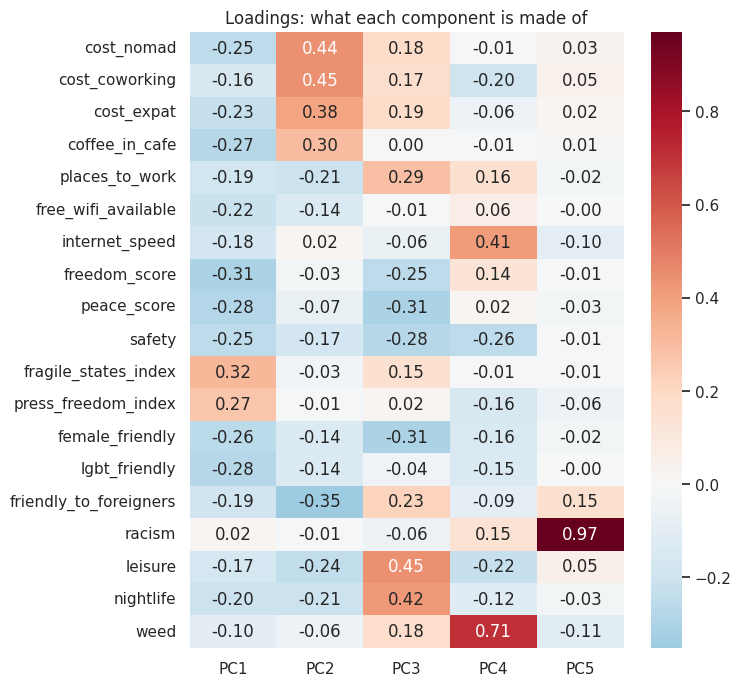

In [31]:
plt.figure(figsize=(7, 8))
sns.heatmap(loadings, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("Loadings: what each component is made of")
plt.show()

---
## Step 6 · The picture

Put the scores in a table alongside the city names, then plot the first two components.

In [32]:
pcs = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"])
pcs["place"] = labels["place"].values
pcs["region"] = labels["region"].values
pcs["life_score"] = labels["life_score"].values

pcs.head()

,PC1,PC2,place,region,life_score
0,-0.485579,-1.552658,Budapest,Europe,0.86
1,1.810962,-1.526793,Chiang Mai,Asia,0.75
2,1.279698,-1.152357,Phuket,Asia,0.75
3,-0.464595,-3.008811,Bangkok,Asia,0.72
4,0.478982,-2.189082,Ko Samui,Asia,0.80


In [51]:
pcs

,PC1,PC2,place,region,life_score,tSNE1,tSNE2,UMAP1,UMAP2
0,-0.485579,-1.552658,Budapest,Europe,0.86,12.758318,10.956758,5.054304,2.504527
1,1.810962,-1.526793,Chiang Mai,Asia,0.75,22.753788,1.943603,2.956184,2.882432
2,1.279698,-1.152357,Phuket,Asia,0.75,23.540134,0.441370,2.950150,3.251639
3,-0.464595,-3.008811,Bangkok,Asia,0.72,14.632906,6.064902,3.847248,2.531046
4,0.478982,-2.189082,Ko Samui,Asia,0.80,14.878860,5.189922,3.851558,2.602319
...,...,...,...,...,...,...,...,...,...
775,3.178798,3.371397,Port Moresby,Oceania,0.31,40.337067,-14.831854,1.298881,5.498489
776,3.844809,3.050257,Freetown,Africa,0.22,40.109245,-15.388138,1.207878,5.556944
777,4.249576,1.415363,Tripoli,Africa,0.22,35.477737,-18.666327,1.434073,5.269020
778,6.005788,2.390400,Damascus,Asia,0.01,38.950550,-18.695347,0.971086,5.416612


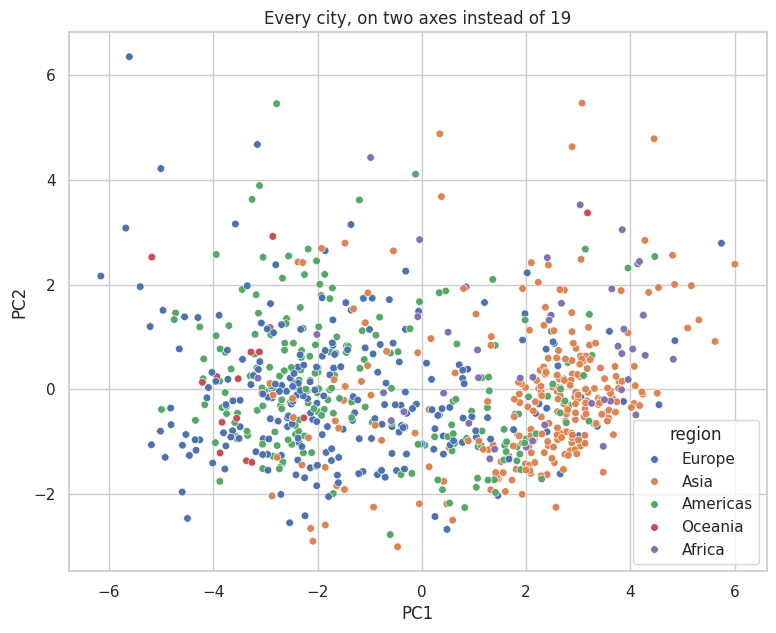

In [33]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=pcs, x="PC1", y="PC2", hue="region", s=30)
plt.title("Every city, on two axes instead of 19")
plt.show()

The same picture again, **interactive** — hover over a dot to see which city it is.

In [34]:
fig = px.scatter(pcs, x="PC1", y="PC2", color="region",
                 hover_name="place", hover_data=["life_score"],
                 title="Every city, on two axes instead of 19")
fig.update_traces(marker_size=9)
fig.show()

**19 columns are now one picture.** And notice: we never told PCA which region a city is in.
It found that structure on its own.

### Which cities are at each end?

In [35]:
pcs.sort_values("PC1").head(10)

,PC1,PC2,place,region,life_score
268,-6.156793,2.163921,Zurich,Europe,0.86
269,-5.678656,3.081028,Geneva,Europe,0.87
272,-5.611262,6.355179,Lausanne,Europe,0.78
391,-5.400776,1.961512,Bergen,Europe,0.84
587,-5.210662,1.200238,Aarhus,Europe,0.83
253,-5.186285,-1.059997,Utrecht,Europe,0.90
243,-5.178356,2.525632,Darwin,Oceania,0.86
153,-5.013269,-0.800034,Antwerp,Europe,0.89
317,-5.004367,4.217992,Venice,Europe,0.81
192,-4.992973,-0.384403,Lethbridge,Americas,0.84


**Exercise: Find Aalborg and Copenhagen, compare them, and describe what you see.**

Filter `pcs` to both cities. Where do they sit on PC1 and PC2? How far apart are they
compared with the rest of the table? Then explain *why* — which columns would be
identical for two cities in the same country?

,PC1,PC2,place,region,life_score,tSNE1,tSNE2,UMAP1,UMAP2
586,-4.965258,1.509624,Copenhagen,Europe,0.84,-33.025257,-4.647446,9.774426,3.903182
588,-4.551136,1.384765,Aalborg,Europe,0.80,-30.909117,-8.707652,10.909815,3.635014


In [36]:
pcs.sort_values("PC1").tail(10)

,PC1,PC2,place,region,life_score
750,4.809254,2.562977,Baghdad,Asia,0.09
739,4.823761,0.574972,Dahab,Africa,0.27
734,4.849734,2.004856,Bahawalpur,Asia,0.11
512,4.854132,0.930471,Obninsk,Europe,0.49
729,5.099088,1.171637,Islamabad,Asia,0.26
766,5.170356,1.979805,Isfahan,Asia,0.45
732,5.313931,1.324913,Gujranwala,Asia,0.11
731,5.625033,0.914492,Rawalpindi,Asia,0.10
358,5.747300,2.791139,Hama,Europe,0.02
778,6.005788,2.390400,Damascus,Asia,0.01


Compare those two lists with the names you gave PC1. Do they match? If yes, you have your
finding. If no, look at the loadings again.

### A free sanity check

Remember we set `life_score` aside in Step 2c. PCA has never seen it. If our components are
picking up something real about cities, one of them should line up with it.

In [37]:
print("PC1 vs life_score:", pcs["PC1"].corr(pcs["life_score"]).round(2))
print("PC2 vs life_score:", pcs["PC2"].corr(pcs["life_score"]).round(2))

PC1 vs life_score: -0.83
PC2 vs life_score: -0.23


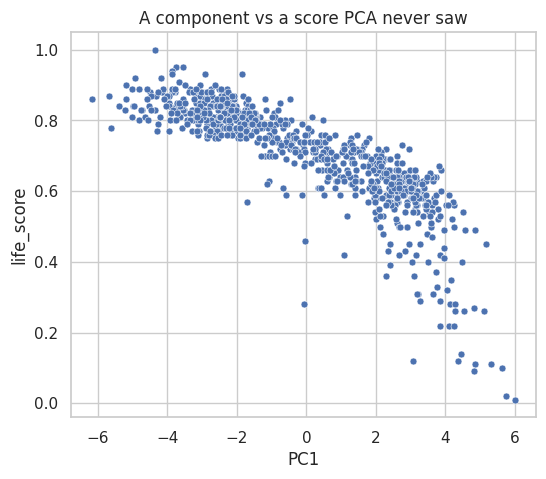

In [38]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=pcs, x="PC1", y="life_score", s=25)
plt.title("A component vs a score PCA never saw")
plt.show()

A strong correlation here is good news: an outside measure agrees with what PCA found.

(And if the number is **negative**, that is the arbitrary-sign thing again — it does not mean
PCA got it backwards.)

---
## t-SNE and UMAP

PCA can only draw **straight lines** through your data. Sometimes the pattern is curved, and
then PCA smears things that should be separate.

**t-SNE** and **UMAP** are two methods that can follow curves. Both do the same job: take your
many columns and place every row on a 2-D map so that **similar rows end up near each other**.

They are for **looking at data**, not for feeding into a model.

### t-SNE

In [39]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_coords = tsne.fit_transform(X)

pcs["tSNE1"] = tsne_coords[:, 0]
pcs["tSNE2"] = tsne_coords[:, 1]

Now plot it — but this time **interactively**. `plotly` draws the same scatter, except that
**hovering over a dot tells you which city it is**. That matters here: the whole point of a t-SNE
map is to go and check whether a cluster is real, and you cannot do that if the dots are anonymous.

`hover_name="place"` is what puts the city name in the tooltip.

In [40]:
fig = px.scatter(pcs, x="tSNE1", y="tSNE2", color="region",
                 hover_name="place", hover_data=["life_score"],
                 title="t-SNE — hover a dot to see the city")
fig.update_traces(marker_size=9)
fig.show()

**Try it.** Pick a cluster, hover over five or six of its dots, and ask: *do these cities belong
together?* Then find a dot sitting on its own and see which city it is.

### UMAP

Same idea, different maths. UMAP is faster, and unlike t-SNE it can place **new** rows onto an
existing map later.

In [41]:
# point tries to stay near its ~15 nearest neighbours
# how tightly points may bunch up — small = tight clumps, large = spread out
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_coords = reducer.fit_transform(X)

pcs["UMAP1"] = umap_coords[:, 0]
pcs["UMAP2"] = umap_coords[:, 1]

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [42]:
fig = px.scatter(pcs, x="UMAP1", y="UMAP2", color="region",
                 hover_name="place", hover_data=["life_score"],
                 title="UMAP — hover a dot to see the city")
fig.update_traces(marker_size=9)
fig.show()

**Compare the two maps.** Find the same three or four cities on both (hover to identify them).
Do they keep the same neighbours? Cities that stay together on *both* maps are a group worth
believing; cities that move are a group the method invented.

> 💡 You can also **double-click a region in the legend** to show only that region, drag a box to
> zoom, and double-click the plot to reset.

### All three side by side

Static, small, and for one purpose only: seeing at a glance how differently the three methods lay
out the *same* cities.

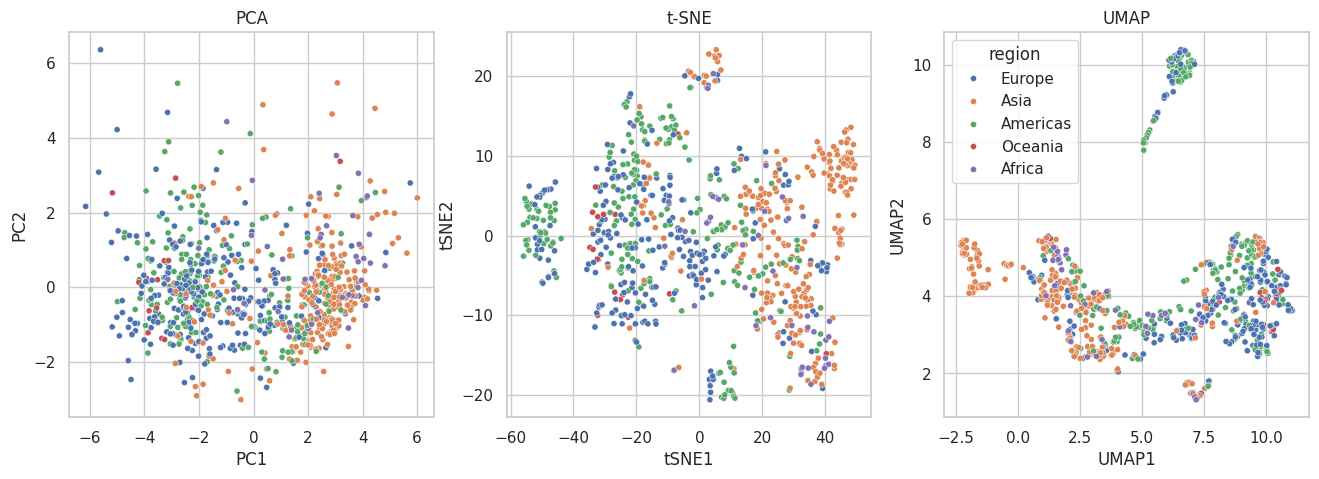

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=pcs, x="PC1", y="PC2", hue="region", s=20, ax=axes[0], legend=False)
sns.scatterplot(data=pcs, x="tSNE1", y="tSNE2", hue="region", s=20, ax=axes[1], legend=False)
sns.scatterplot(data=pcs, x="UMAP1", y="UMAP2", hue="region", s=20, ax=axes[2])

axes[0].set_title("PCA")
axes[1].set_title("t-SNE")
axes[2].set_title("UMAP")
plt.show()

### ⚠️ Four rules for reading t-SNE and UMAP plots

These plots are easy to over-read. Four rules that will keep you out of trouble:

1. **The distance between two blobs means nothing.** Two groups far apart are *not* more
   different than two groups close together.
2. **The size of a blob means nothing.** A big blob is not a big group.
3. **The axes mean nothing.** There is no "tSNE1 = cost". Never label them, never use them in a
   model.
4. **Random noise makes convincing-looking clusters.** Prove it to yourself in Exercise 5.

So: a cluster in one of these plots is a **question to go and check**, never an answer. Go back
to the original columns and show that the group really is different on something you can name.

**PCA does not have this problem** — its axes have exact meanings (the loadings) and its distances
are real. That is why you start with PCA.

---
## The whole thing, on one page

```python
# 1. load
cities = pd.read_csv(url)

# 2. clean
cities = cities.drop(columns="cost_beer")
features = cities.drop(columns=["place", "alpha-2", "region", "sub-region", "life_score"])
features = features.fillna(features.median())

# 3. standardise            <- do not skip this
X = StandardScaler().fit_transform(features)

# 4. run
pca = PCA(n_components=5, random_state=42)
scores = pca.fit_transform(X)

# 5. read
pca.explained_variance_ratio_                      # how much you kept
pd.DataFrame(pca.components_.T,
             index=features.columns).iloc[:, 0].sort_values()   # what PC1 means

# 6. plot
sns.scatterplot(x=scores[:, 0], y=scores[:, 1])
```

**Five mistakes to avoid**

| ✗ Don't | ✓ Do |
|---|---|
| Run PCA on raw, unscaled numbers | `StandardScaler()` first, every time |
| Say "PC1 is cost" because cost loads highest | PC1 is a **contrast** — read the whole sorted list |
| Read anything into a component's + or − sign | Signs are arbitrary. Only contrasts matter |
| Believe the gaps in a t-SNE plot | Distances and blob sizes there mean nothing |
| Keep 5 components "because that is normal" | Pick a rule, and say which one in your report |

---
## Exercises 2–5

Four short ones.
The solutions are in the separate solutions notebook — try these first.

**Exercise 2 — Prove that standardising matters.**

Run PCA on `features` *without* scaling and look at the top loadings of PC1. Then divide
`cost_expat` by 1000 (dollars → thousands), run it again, and look at the top loadings once more.
Did the "most important" column change? What does that tell you?

In [44]:
# Exercise 2 -- your code here


**Exercise 3 — Name PC3.**

Sort the `PC3` column of `loadings`. Write down the two ends of the contrast, and give the
component a short name. Then find the 5 cities with the highest PC3 score and check whether the
name still fits.

*Hint: you will need a third column in `pcs`, from `scores[:, 2]`.*

In [45]:
# Exercise 3 -- your code here


**Exercise 4 — Find your own city.**

Filter `pcs` to a city you know (or one from your home country). Where does it sit on PC1 and
PC2? Which cities are its nearest neighbours in the plot? Does that match your intuition?

In [46]:
# Exercise 4 -- your code here


**Exercise 5 — Break t-SNE on purpose.**

Make 400 rows of **completely random numbers** with 20 columns, then run t-SNE on it and plot the
result. There is no structure in that data at all. Do you see clusters anyway?

*Hint: `np.random.normal(size=(400, 20))`*

In [47]:
# Exercise 5 -- your code here


---
## Want more?

There is a longer **deep-dive notebook** that covers the same dataset in much more detail:
factor analysis, autoencoders, reconstruction error, the curse of dimensionality, and a section
on why the obvious way of validating a model on this data gives badly misleading results.

**To read next**

* James, Witten, Hastie & Tibshirani, *An Introduction to Statistical Learning* — chapter 12.
  Free PDF from the authors, and the right level for this course.
* [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/) — interactive, fifteen
  minutes, and it will change how you read every t-SNE plot you are ever shown.
* [scikit-learn's decomposition guide](https://scikit-learn.org/stable/modules/decomposition.html)